# HW02 —  EDA

## Используемый датасет
В данной работе оспользовался [набор данных](https://www.kaggle.com/datasets/dmahajanbe23/bmw-global-automotive-sales) BMW Global Automotive Sales. Данный набор данных представляет собой высокодетализированную структурированную реконструкцию глобальных поставок автомобилей BMW Group, доли рынка в премиальном сегменте, уровня проникновения электромобилей и макроэкономических показателей за период с 2018 по 2025 год.

---

## A) Быстрый обзор данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style('darkgrid')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

df = pd.read_csv('bmw_global_sales_2018_2025.csv')

# Проверка загрузки файла
display(df.head())
display(df.sample(5))
display(df.tail())

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
1580,2022,2,China,X7,6104,90365,551587960,0.122,15.26,4.41,1.20
1811,2022,9,USA,X5,6843,67688,463188984,0.118,18.12,3.76,1.22
2834,2025,5,USA,X3,5408,56921,307828768,0.204,15.22,2.38,1.33
1949,2023,1,RestOfWorld,i4,13022,63696,829449312,0.160,6.53,3.03,1.31
2687,2024,12,RestOfWorld,MINI,5263,43633,229640479,0.173,5.96,4.65,1.35


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
3067,2025,12,RestOfWorld,X5,9281,68198,632945638,0.201,5.89,2.37,1.41
3068,2025,12,RestOfWorld,X7,12785,91839,1174161615,0.203,5.89,2.37,1.41
3069,2025,12,RestOfWorld,i4,4906,63437,311221922,0.180,5.89,2.37,1.41
3070,2025,12,RestOfWorld,iX,7871,73867,581407157,0.196,5.89,2.37,1.41
3071,2025,12,RestOfWorld,MINI,6732,41811,281471652,0.167,5.89,2.37,1.41


In [2]:
# Развер датасета и информация о колонках
print(df.shape)
df.info()

(3072, 11)
<class 'pandas.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   str    
 3   Model             3072 non-null   str    
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), str(2)
memory usage: 264.1 KB


In [3]:
# Статистика
display(df.describe())
display(df.describe(include='string'))

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
count,3072.000000,3072.000000,3072.000000,3072.000000,3.072000e+03,3072.000000,3072.000000,3072.000000,3072.000000
mean,2021.500000,6.500000,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
std,2.291661,3.452615,3174.917444,14655.891299,2.431185e+08,0.058099,5.334604,1.018103,0.118123
min,2018.000000,1.000000,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
25%,2019.750000,3.750000,5225.500000,54500.250000,3.125504e+08,0.057000,12.275000,2.370000,1.080000
50%,2021.500000,6.500000,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
75%,2023.250000,9.250000,10528.250000,71489.500000,6.709141e+08,0.157250,18.932500,3.852500,1.270000
max,2025.000000,12.000000,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000


,Region,Model
count,3072,3072
unique,4,8
top,Europe,3 Series
freq,768,384


In [4]:
# Проверка качества данных
print(df.isnull().sum())

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


In [6]:
print(df.dtypes)

Year                  int64
Month                 int64
Region                  str
Model                   str
Units_Sold            int64
Avg_Price_EUR         int64
Revenue_EUR           int64
BEV_Share           float64
Premium_Share       float64
GDP_Growth          float64
Fuel_Price_Index    float64
dtype: object


## B) Пропуски и очистка

In [7]:
# Дополнительная информация в виде прокентов
pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean()*100
}).sort_values('percent', ascending=False)

,count,percent
Year,0,0.0
Month,0,0.0
Region,0,0.0
Model,0,0.0
Units_Sold,0,0.0
Avg_Price_EUR,0,0.0
Revenue_EUR,0,0.0
BEV_Share,0,0.0
Premium_Share,0,0.0
GDP_Growth,0,0.0


Продемонстрируем работу `mean`, `median`, `constant`, где это
было бы правильно:

In [8]:
df['Year'].fillna(df['Year'].mean())

0       2018
1       2018
2       2018
3       2018
4       2018
        ... 
3067    2025
3068    2025
3069    2025
3070    2025
3071    2025
Name: Year, Length: 3072, dtype: int64

In [9]:
df['Avg_Price_EUR'].fillna(df['Avg_Price_EUR'].median())

0       47482
1       61685
2       58433
3       67955
4       92300
        ...  
3067    68198
3068    91839
3069    63437
3070    73867
3071    41811
Name: Avg_Price_EUR, Length: 3072, dtype: int64

In [10]:
df['Fuel_Price_Index'].fillna(1)

0       1.00
1       1.00
2       1.00
3       1.00
4       1.00
        ... 
3067    1.41
3068    1.41
3069    1.41
3070    1.41
3071    1.41
Name: Fuel_Price_Index, Length: 3072, dtype: float64

In [11]:
df['GDP_Growth'].fillna(df['GDP_Growth'].mode()[0])

0       3.50
1       3.50
2       3.50
3       3.50
4       3.50
        ... 
3067    2.37
3068    2.37
3069    2.37
3070    2.37
3071    2.37
Name: GDP_Growth, Length: 3072, dtype: float64

##  C) Расширенная статистика

In [12]:
num_col = df.select_dtypes(include=['number'])
stats = num_col.agg(['min', 'max', 'mean', 'median'])
stats.loc['mode'] = num_col.mode().iloc[0]
display(stats)

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
min,2018.0,1.0,2379.000000,40011.000000,1.045314e+08,-0.015000,5.090000,0.100000,0.920000
max,2025.0,12.0,15914.000000,93994.000000,1.433482e+09,0.223000,20.970000,5.820000,1.410000
mean,2021.5,6.5,7980.288086,63854.561523,5.113995e+08,0.107572,14.660234,3.057526,1.176224
median,2021.5,6.5,7985.500000,63493.000000,4.808690e+08,0.108000,16.260000,3.060000,1.180000
mode,2018.0,1.0,5827.000000,42933.000000,1.045314e+08,0.119000,6.870000,2.370000,1.180000


In [13]:
display(num_col.quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0.05,2018.00,1.00,3239.65,41648.15,1.838523e+08,0.01900,5.4100,1.3300,0.99
0.25,2019.75,3.75,5225.50,54500.25,3.125504e+08,0.05700,12.2750,2.3700,1.08
0.50,2021.50,6.50,7985.50,63493.00,4.808690e+08,0.10800,16.2600,3.0600,1.18
0.75,2023.25,9.25,10528.25,71489.50,6.709141e+08,0.15725,18.9325,3.8525,1.27
0.95,2025.00,12.00,13139.15,92369.90,9.499781e+08,0.19700,20.6000,4.6200,1.36


Посчитаем дисперсию, асимметрию и эксцесс:

In [14]:
num_col.var()

Year                5.251710e+00
Month               1.192055e+01
Units_Sold          1.008010e+07
Avg_Price_EUR       2.147951e+08
Revenue_EUR         5.910662e+16
BEV_Share           3.375459e-03
Premium_Share       2.845800e+01
GDP_Growth          1.036535e+00
Fuel_Price_Index    1.395304e-02
dtype: float64

Дисперсия переменной `Revenue_EUR` чрезвычайно высока по сравнению с другими переменными, что ожидаемо, поскольку выручка является произведением цены и количества проданных единиц. Это указывает на очень широкий разброс значений выручки.

In [15]:
num_col.skew()

Year                0.000000
Month               0.000000
Units_Sold          0.134863
Avg_Price_EUR       0.368041
Revenue_EUR         0.655543
BEV_Share          -0.003549
Premium_Share      -0.783498
GDP_Growth         -0.033377
Fuel_Price_Index   -0.021513
dtype: float64

Такие переменные, как `Units_Sold`, `BEV_Share` и `Fuel_Price_Index`, показывают сильную отрицательную асимметрию, что указывает на то, что большинство сосредоточено в области высоких значений, с небольшим количеством более низких значений.

In [16]:
num_col.kurtosis()

Year               -1.238157
Month              -1.216810
Units_Sold         -1.000073
Avg_Price_EUR      -0.429139
Revenue_EUR         0.025543
BEV_Share          -1.177494
Premium_Share      -0.910234
GDP_Growth         -0.418522
Fuel_Price_Index   -1.015473
dtype: float64

Большинство переменных демонстрируют отрицательный эксцесс, что указывает на более плоское распределение по сравнению с нормальным распределением и меньшую вероятность экстремальных выбросов.

## D) Энкодинг и инжиниринг

In [17]:
cat_cols = df.select_dtypes(include='string').columns
cardinality = df[cat_cols].nunique(dropna=False).sort_values(ascending=False)
display(cardinality.to_frame('n_unique'))

,n_unique
Model,8
Region,4


In [18]:
# OneHotEncoder
df_data = pd.get_dummies(df, columns=cat_cols, drop_first = True, dtype = int)
df_data.sample(10)

,Year,Month,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Region_Europe,Region_RestOfWorld,Region_USA,Model_5 Series,Model_MINI,Model_X3,Model_X5,Model_X7,Model_i4,Model_iX
2850,2025,6,7679,57101,438478579,0.206,18.81,3.25,1.35,1,0,0,0,0,1,0,0,0,0
1955,2023,2,6274,67648,424423552,0.141,14.93,4.60,1.24,1,0,0,0,0,0,1,0,0,0
1466,2021,10,7327,57462,421024074,0.087,6.19,3.94,1.16,0,1,0,0,0,1,0,0,0,0
2106,2023,6,6165,58058,357927570,0.144,5.82,1.42,1.27,0,1,0,0,0,1,0,0,0,0
1077,2020,10,8434,64493,543933962,0.073,18.70,1.86,1.10,0,0,1,0,0,0,0,0,1,0
2402,2024,4,8325,57529,478928925,0.176,16.13,3.25,1.23,1,0,0,0,0,1,0,0,0,0
3045,2025,12,4806,65710,315802260,0.211,20.15,2.50,1.35,1,0,0,0,0,0,0,0,1,0
902,2020,5,11641,74283,864728403,0.072,17.21,1.69,1.11,1,0,0,0,0,0,0,0,0,1
770,2020,1,7713,58607,452035791,0.052,17.80,2.26,1.09,1,0,0,0,0,1,0,0,0,0
2730,2025,2,3549,59838,212365062,0.187,20.36,5.25,1.34,0,0,0,0,0,1,0,0,0,0


Хэширование признаков - это метод кодирования, используемый для переменных типа "категория" с высокой кардинальностью. Он сопоставляет категории с фиксированным числом с помощью хэш-функции.

В текущем датасете хэширование признаков не применялось, поскольку в нем отсутствуют категориальные переменные с высокой кардинальностью, для которых этот подход был бы полезен.

Генерация новых признаков:

In [19]:
df['Avg_Price_per_unit'] = df['Revenue_EUR'] / df['Units_Sold']
df['Price_difference'] = df['Avg_Price_EUR'] - df.groupby('Model')['Avg_Price_EUR'].transform('mean')
df['Price_ratio'] = df['Avg_Price_EUR'] / df.groupby('Model')['Avg_Price_EUR'].transform('mean')
display(df.head())

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index,Avg_Price_per_unit,Price_difference,Price_ratio
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0,47482.0,-504.494792,0.989487
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0,61685.0,-250.234375,0.995960
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0,58433.0,414.447917,1.007143
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0,67955.0,-985.979167,0.985698
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0,92300.0,293.510417,1.003190


## E) Визуализация данных

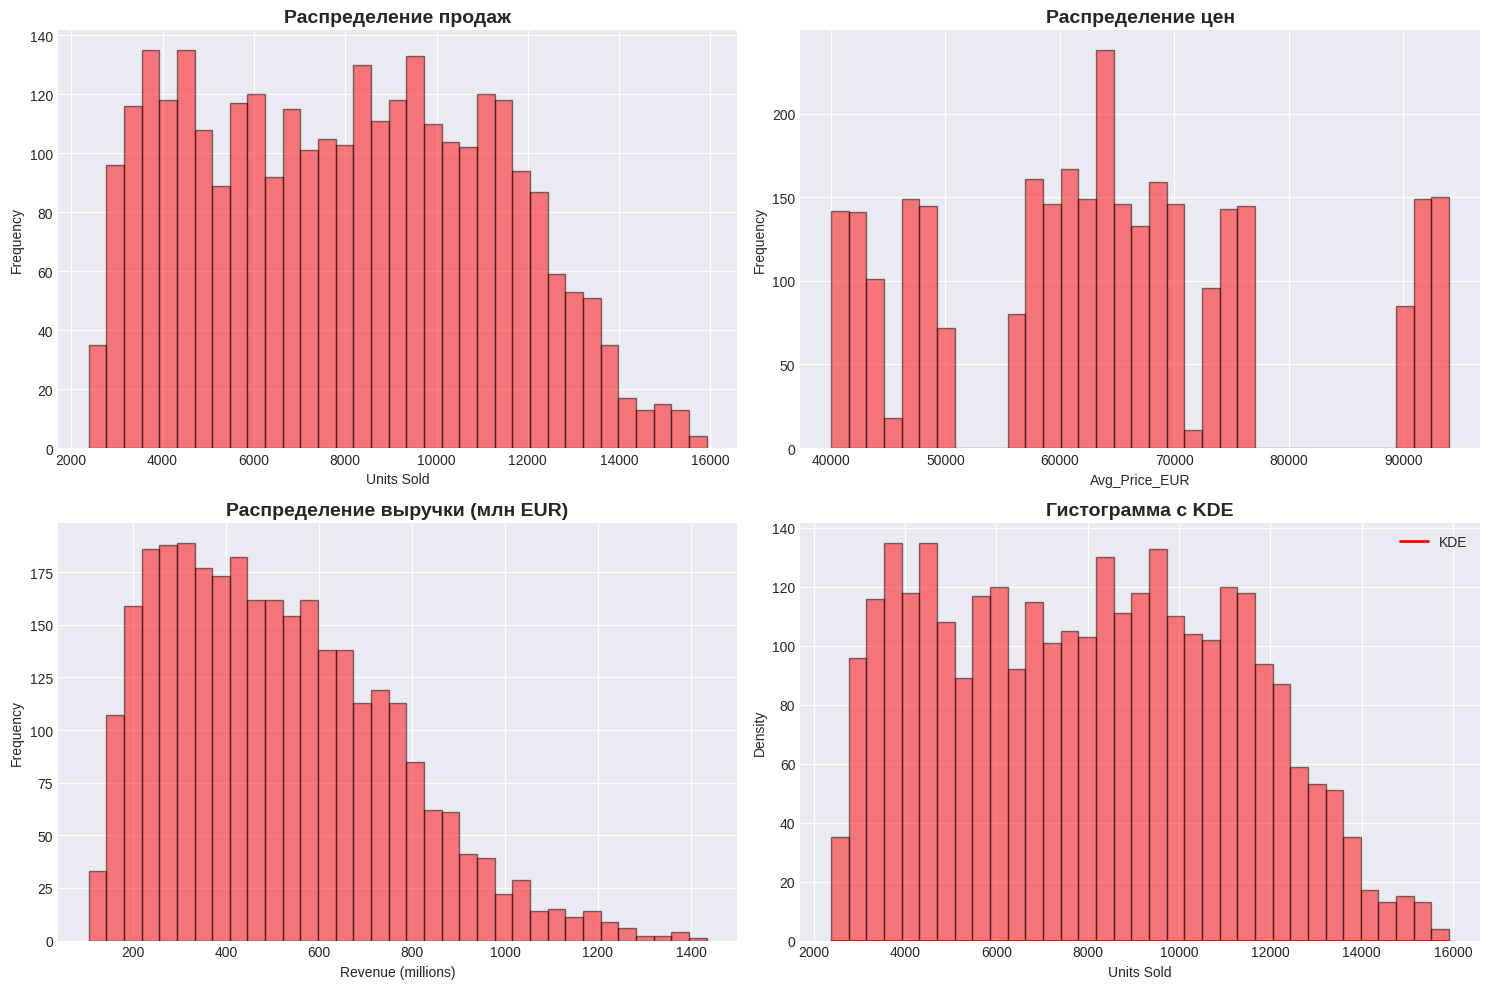

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes[0, 0].hist(df['Units_Sold'], bins=35, edgecolor='black', alpha=0.5, color='red')
axes[0, 0].set_title('Распределение продаж', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Units Sold')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df['Avg_Price_EUR'], bins=35, edgecolor='black', alpha=0.5, color='red')
axes[0, 1].set_title('Распределение цен', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Avg_Price_EUR')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(df['Revenue_EUR']/1e6, bins=35, edgecolor='black', alpha=0.5, color='red')
axes[1, 0].set_title('Распределение выручки (млн EUR)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Revenue (millions)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(df['Units_Sold'], bins=35, edgecolor='black', alpha=0.5, color='red')
axes[1, 1].set_title('Гистограмма с KDE', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Units Sold')
axes[1, 1].set_ylabel('Density')

from scipy import stats
density = stats.gaussian_kde(df['Units_Sold'])
x_vals = np.linspace(df['Units_Sold'].min(), df['Units_Sold'].max(), 200)
axes[1, 1].plot(x_vals, density(x_vals), 'r-', linewidth=2, label='KDE')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

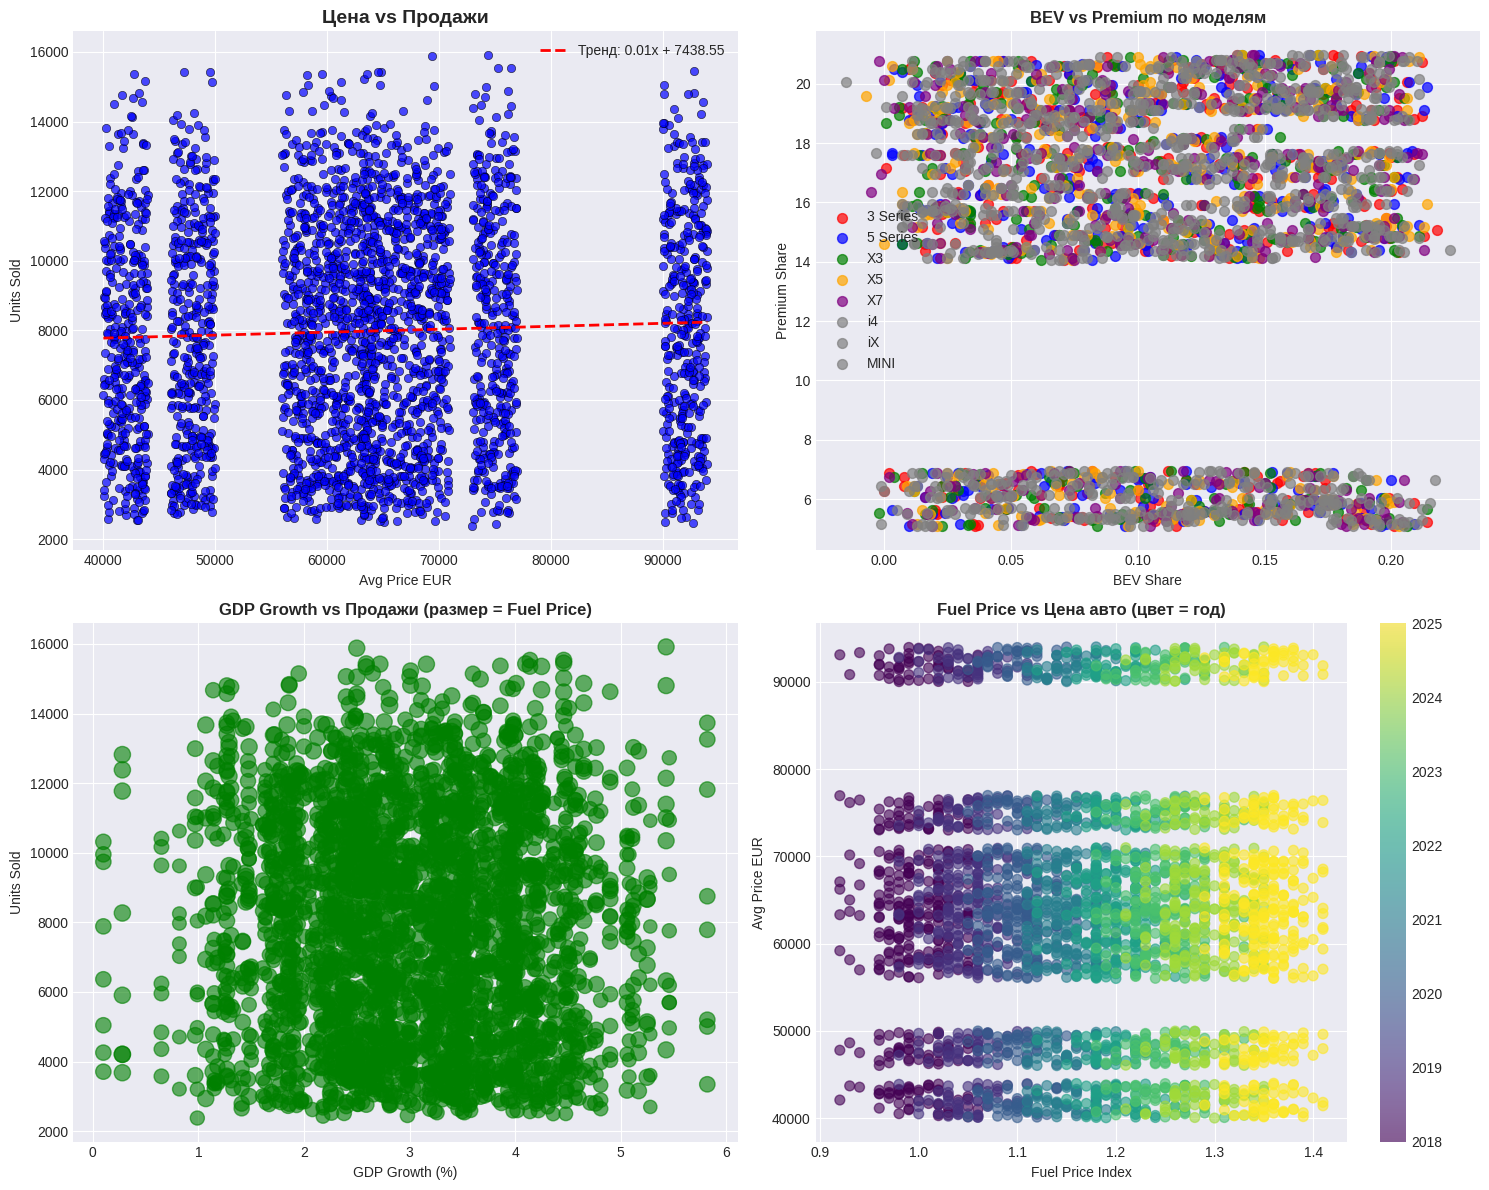

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Цена vs Продажи
axes[0, 0].scatter(df['Avg_Price_EUR'], df['Units_Sold'], alpha=0.7, c='blue', edgecolors='black', linewidth=0.5)
axes[0, 0].set_xlabel('Avg Price EUR')
axes[0, 0].set_ylabel('Units Sold')
axes[0, 0].set_title('Цена vs Продажи', fontsize=14, fontweight='bold')

# Линия тренда
z = np.polyfit(df['Avg_Price_EUR'], df['Units_Sold'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['Avg_Price_EUR'].sort_values(), p(df['Avg_Price_EUR'].sort_values()), 'r--', linewidth=2, label=f'Тренд: {z[0]:.2f}x + {z[1]:.2f}')
axes[0, 0].legend()

# BEV Share vs Premium Share
colors = {'3 Series': 'red', '5 Series': 'blue', 'X3': 'green', 'X5': 'orange', 'X7': 'purple'}
for model in df['Model'].unique():
    model_data = df[df['Model'] == model]
    axes[0, 1].scatter(model_data['BEV_Share'], model_data['Premium_Share'], c=colors.get(model, 'gray'), label=model, alpha=0.7, s=50)
axes[0, 1].set_xlabel('BEV Share')
axes[0, 1].set_ylabel('Premium Share')
axes[0, 1].set_title('BEV vs Premium по моделям', fontsize=12, fontweight='bold')
axes[0, 1].legend()

# GDP Growth vs Sales
axes[1, 0].scatter(df['GDP_Growth'], df['Units_Sold'], alpha=0.6, c='green', s=df['Fuel_Price_Index']*100)
axes[1, 0].set_xlabel('GDP Growth (%)')
axes[1, 0].set_ylabel('Units Sold')
axes[1, 0].set_title('GDP Growth vs Продажи (размер = Fuel Price)', fontsize=12, fontweight='bold')

# Fuel Price vs Price
axes[1, 1].scatter(df['Fuel_Price_Index'], df['Avg_Price_EUR'], 
                   alpha=0.6, c=df['Year'], cmap='viridis', s=50)
axes[1, 1].set_xlabel('Fuel Price Index')
axes[1, 1].set_ylabel('Avg Price EUR')
axes[1, 1].set_title('Fuel Price vs Цена авто (цвет = год)', fontsize=12, fontweight='bold')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])

plt.tight_layout()
plt.show()

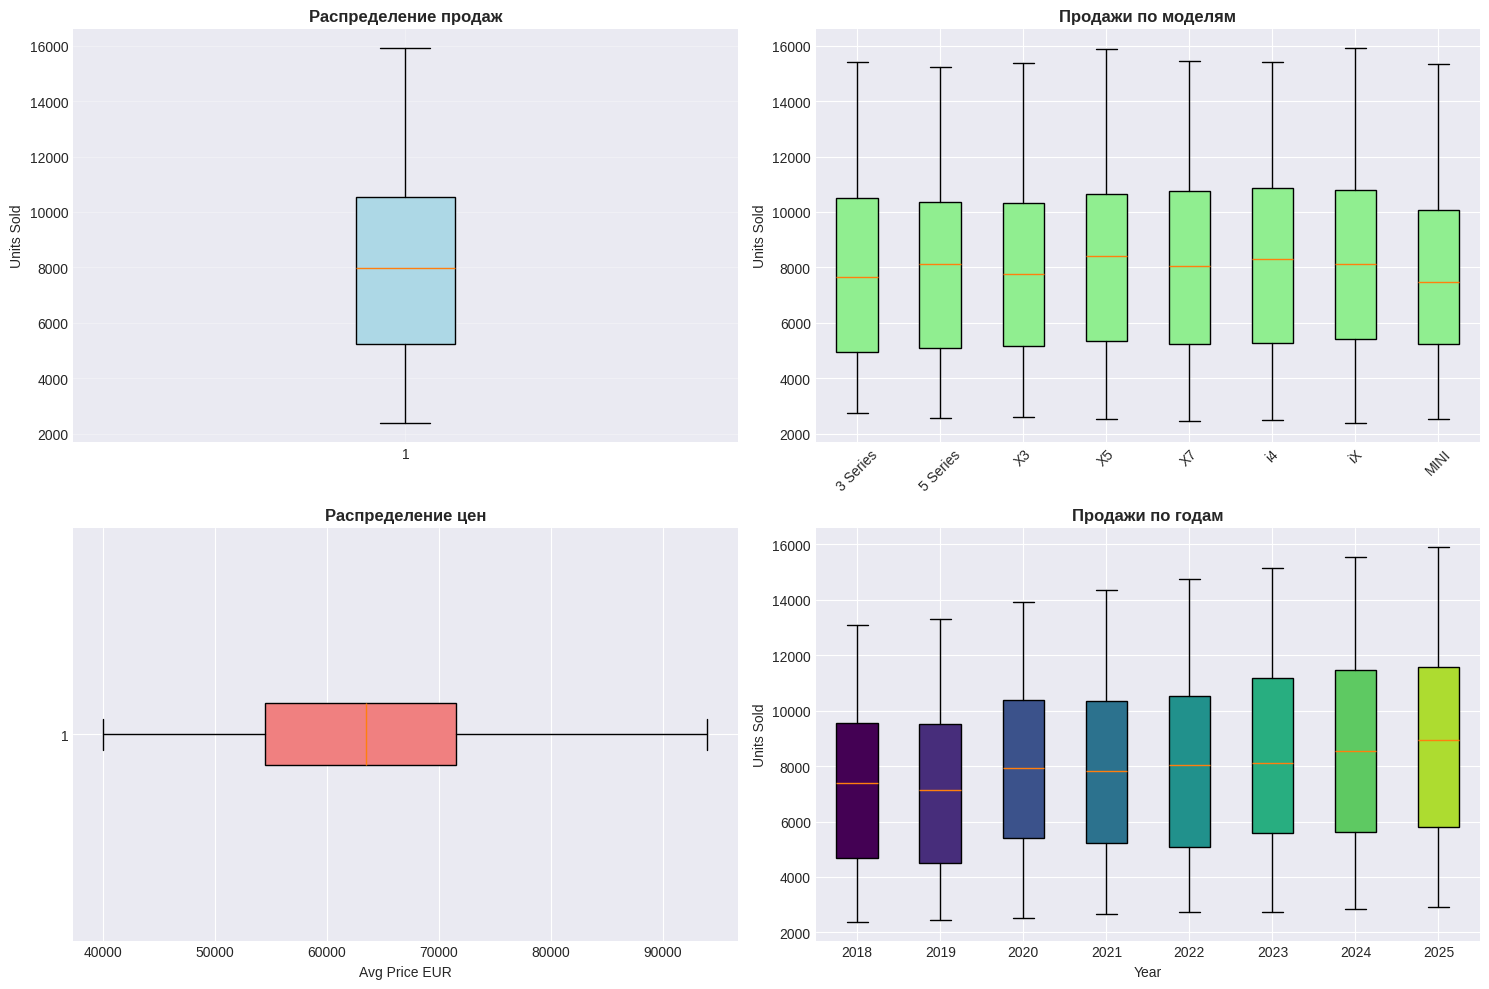

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Боксплот продаж
bp1 = axes[0, 0].boxplot(df['Units_Sold'], vert=True, patch_artist=True)
bp1['boxes'][0].set_facecolor('lightblue')
axes[0, 0].set_title('Распределение продаж', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Units Sold')
axes[0, 0].grid(True, alpha=0.3)

# Боксплот по моделям
data_by_model = [df[df['Model'] == model]['Units_Sold'].values for model in df['Model'].unique()]
bp2 = axes[0, 1].boxplot(data_by_model, tick_labels=df['Model'].unique(), patch_artist=True)
for box in bp2['boxes']:
    box.set_facecolor('lightgreen')
axes[0, 1].set_title('Продажи по моделям', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Units Sold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Горизонтальный боксплот
bp3 = axes[1, 0].boxplot(df['Avg_Price_EUR'], vert=False, patch_artist=True)
bp3['boxes'][0].set_facecolor('lightcoral')
axes[1, 0].set_title('Распределение цен', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Avg Price EUR')

# Боксплот с разбивкой по годам
data_by_year = [df[df['Year'] == year]['Units_Sold'].values for year in sorted(df['Year'].unique())]
bp4 = axes[1, 1].boxplot(data_by_year, tick_labels=sorted(df['Year'].unique()), patch_artist=True)
for i, box in enumerate(bp4['boxes']):
    box.set_facecolor(plt.cm.viridis(i/len(data_by_year)))
axes[1, 1].set_title('Продажи по годам', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Units Sold')
axes[1, 1].set_xlabel('Year')

plt.tight_layout()
plt.show()

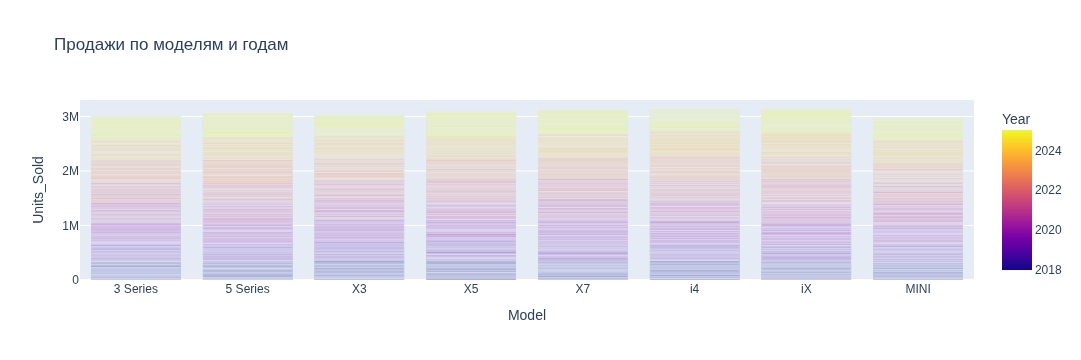

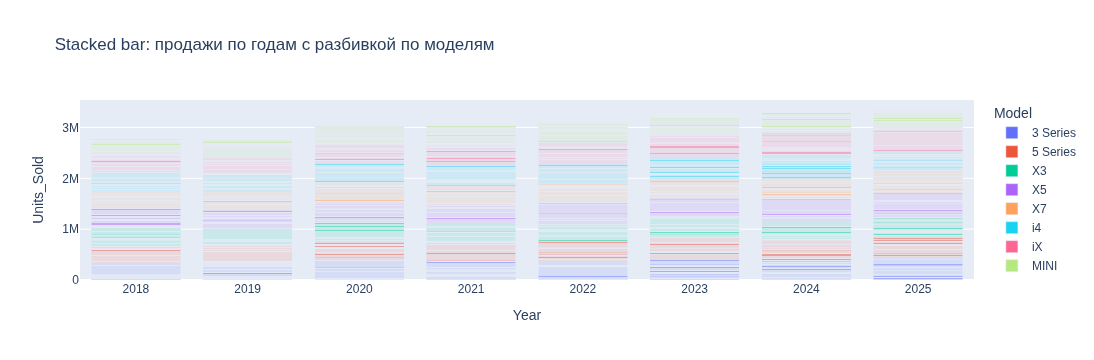

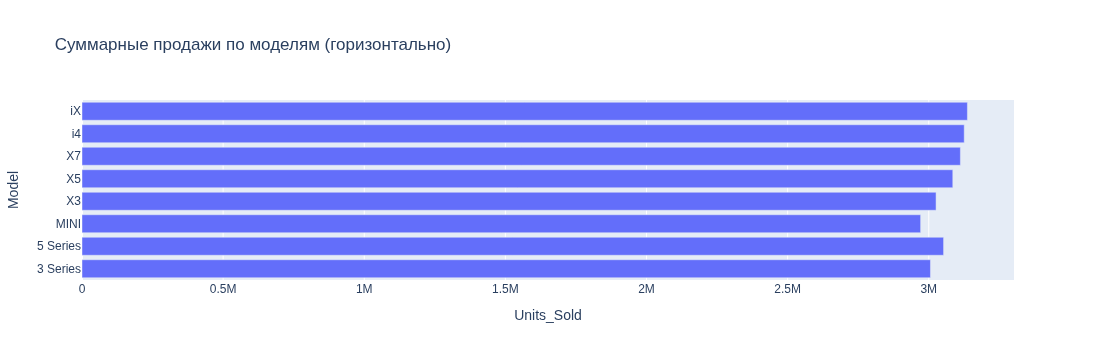

In [23]:
# Интерактивный bar chart
fig = px.bar(df, x='Model', y='Units_Sold', color='Year', barmode='group', title='Продажи по моделям и годам', hover_data=['Month', 'Revenue_EUR'])
fig.show()

# Stacked bar chart
fig = px.bar(df, x='Year', y='Units_Sold', color='Model', barmode='stack', title='Stacked bar: продажи по годам с разбивкой по моделям')
fig.show()

# Горизонтальный бар
fig = px.bar(df.groupby('Model').agg({'Units_Sold': 'sum'}).reset_index(), y='Model', x='Units_Sold', orientation='h', title='Суммарные продажи по моделям (горизонтально)')
fig.show()

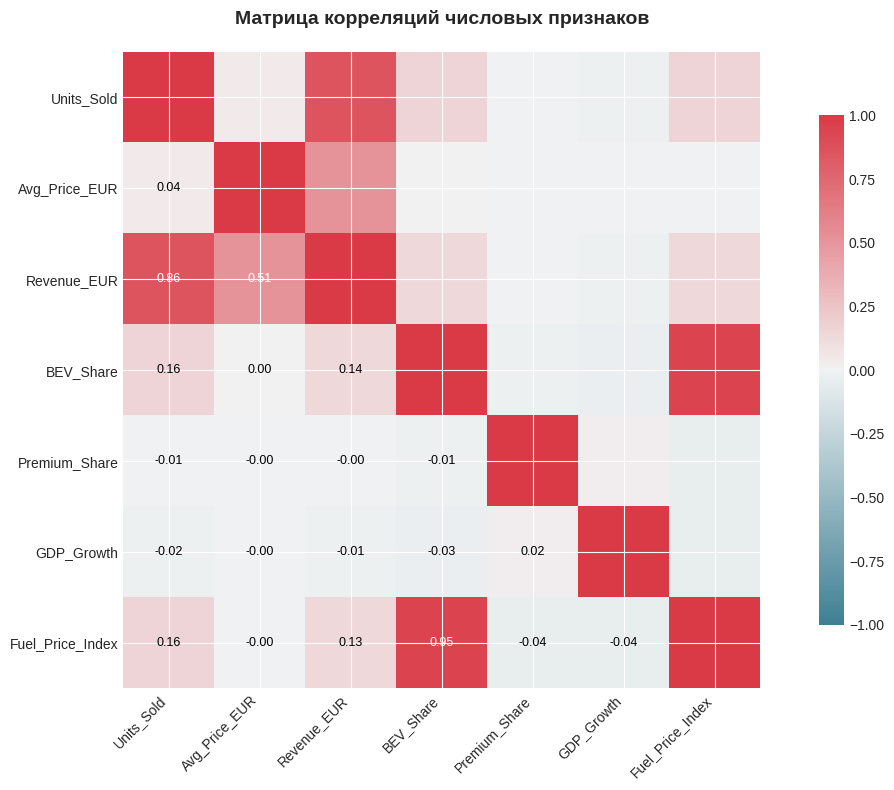

In [24]:
numeric_cols = ['Units_Sold', 'Avg_Price_EUR', 'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth', 'Fuel_Price_Index']

# Считаем корреляцию
corr_matrix = df[numeric_cols].corr()

# Создаем heatmap
fig, ax = plt.subplots(figsize=(12, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
im = ax.imshow(corr_matrix, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

# Настраиваем оси
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(numeric_cols, fontsize=10)

# Добавляем значения корреляции в ячейки
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if not mask[i, j]:  # если не в верхнем треугольнике
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=9,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

ax.set_title('Матрица корреляций числовых признаков', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Сильная корреляция наблюдается у `Units_Sold` и `BEV_Share`

##  F) Итоговые выводы

На основе предоставленных визуализаций и корреляционного анализа можно сделать следующие выводы о датасете:
1. Корреляционная матрица показывает, что большинство признаков слабо коррелируют между собой. Наибольшая корреляция (около 0.51) наблюдается между средней ценой и выручкой – что логично, поскольку выручка прямо зависит от цены и объёма продаж.
2. Продажи практически не коррелируют с ростом ВВП и индексом цен на топливо (коэффициенты близки к нулю). Возможно, за рассматриваемый период эти показатели были стабильны, либо влияние макроэкономики нивелируется другими факторами.
3.  Гистограмма продаж показывает несколько пиков, соответствующих разным моделям. Например, 5 Series продаётся существенно больше, чем X3. Это говорит о разной популярности моделей
4.  Цены на автомобили варьируются от 40 000 до 90 000 евро, с концентрацией в районе 50 000–70 000. Самые дорогие модели (X7) имеют цену около 92 000 евро

### Гипотезы и наблюдения:

1. Положительная, хоть и слабая, корреляция между долей электромобилей и объёмом продаж может быть связана с расширением модельного ряда BMW в сторону электрификации.
2. На boxplot могут присутствовать выбросы - например, аномально высокие продажи 5 Series в декабре (возможно из-за скидок) или аномально низкие - из-за смены поколений модели. Такие точки стоит исследовать отдельно и, возможно, удалить или заменить на средние для повышения качества модели.
3. Разные модели имеют разную целевую аудиторию и ценовые сегменты. Это подтверждается boxplot: у X3 продажи значительно ниже, чем у 5 Series. Следовательно, модель должна учитывать индивидуальные особенности каждой модели.

### Что бы я делал дальше:
В зависимости от бизнес-задачи можно было бы предсказывать:

1. Units_Sold (регрессия) - для прогнозирования спроса.
2. Revenue_EUR (регрессия) - для планирования выручки.
3. BEV_Share (регрессия) - для понимания динамики электрификации.

Также можно построить классификатор для определения, будет ли продажи модели выше среднего.

### Использование ИИ:
Создание графиков, решение возникающих вопросов в ходе выполнения задания.